In [1]:
import numpy as np
import pandas as pd
from pandas_datareader import data as wb
import matplotlib.pyplot as plt
import yfinance as yf
import datetime
import math as m
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
%matplotlib inline
from mpl_toolkits.mplot3d import Axes3D

In [2]:
# ======================================================================
# Quantitative Portfolio Analysis: Risk, Return & Beta
# ======================================================================
# Author  : Angelos
# Assets  : NVDA, LMT, PANW, NEE, SPOT
# Benchmark: S&P 500 (^GSPC)
# Period  : 2020-01-01 to Today
# ======================================================================

# Imports & Data Collection

In [3]:
# ======================================================================
# SECTION 1 — Data Collection
# ======================================================================

stocks    = ["NVDA", "LMT", "PANW", "NEE", "SPOT"]
benchmark = ["^GSPC"]
all_tickers = stocks + benchmark

data = yf.download(all_tickers, start="2020-01-01")["Close"]

print("Shape  :", data.shape)
print("Columns:", list(data.columns))
print("\nFirst rows:")
print(data.head())
print("\nLast rows:")
print(data.tail())
print("\nMissing values per column:")
print(data.isnull().sum())

[*********************100%***********************]  6 of 6 completed

Shape  : (1596, 6)
Columns: ['LMT', 'NEE', 'NVDA', 'PANW', 'SPOT', '^GSPC']

First rows:
Ticker             LMT        NEE      NVDA       PANW        SPOT  \
Date                                                                 
2020-01-02  337.609161  51.085972  5.970754  39.235001  151.619995   
2020-01-03  349.756958  51.449917  5.875185  39.471668  152.500000   
2020-01-06  349.224365  51.706825  5.899823  40.043331  156.720001   
2020-01-07  350.399475  51.661858  5.971251  40.273335  156.020004   
2020-01-08  347.466125  51.638306  5.982451  39.761665  158.779999   

Ticker            ^GSPC  
Date                     
2020-01-02  3257.850098  
2020-01-03  3234.850098  
2020-01-06  3246.280029  
2020-01-07  3237.179932  
2020-01-08  3253.050049  

Last rows:
Ticker             LMT        NEE        NVDA        PANW        SPOT  \
Date                                                                    
2026-05-04  518.150024  95.510002  198.479996  184.559998  438.260010   
2026-05

# Normalization & Price Performance

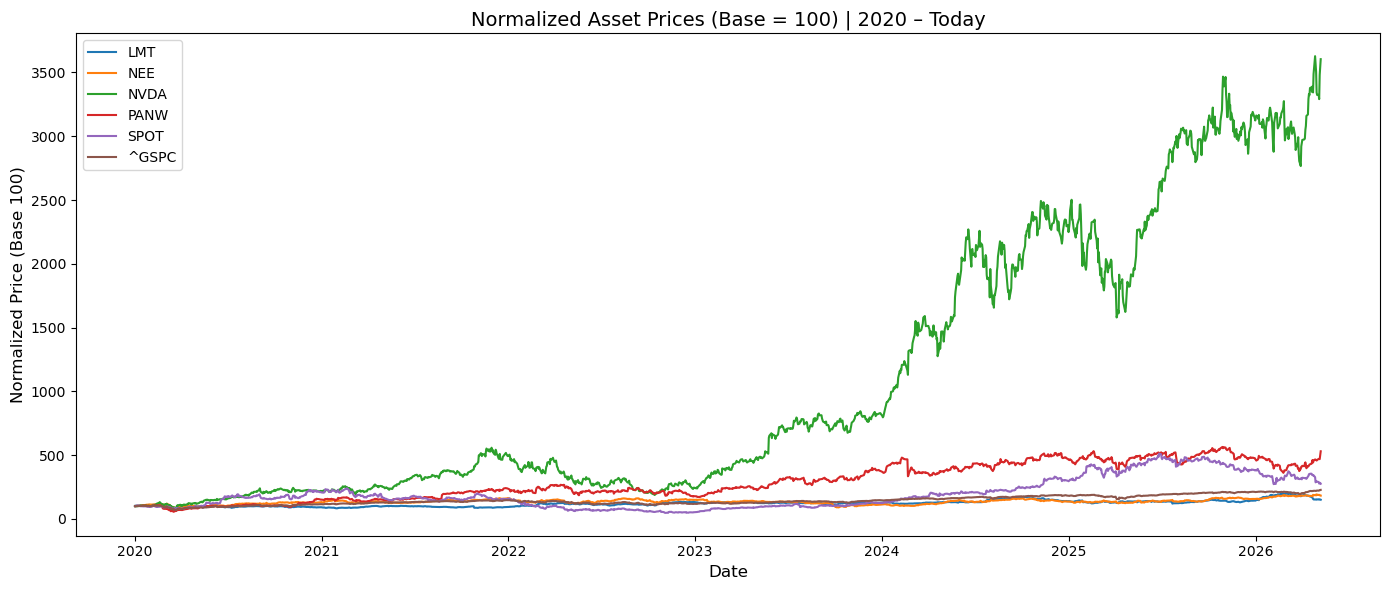

In [4]:
# ======================================================================
# SECTION 2 — Normalization & Price Performance
# ======================================================================

normalization = (data / data.iloc[0]) * 100
 
plt.figure(figsize=(14, 6))
for col in normalization.columns:
    plt.plot(normalization[col], label=col)
 
plt.title("Normalized Asset Prices (Base = 100) | 2020 – Today", fontsize=14)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Normalized Price (Base 100)", fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

# Log Returns & Individual Asset Risk

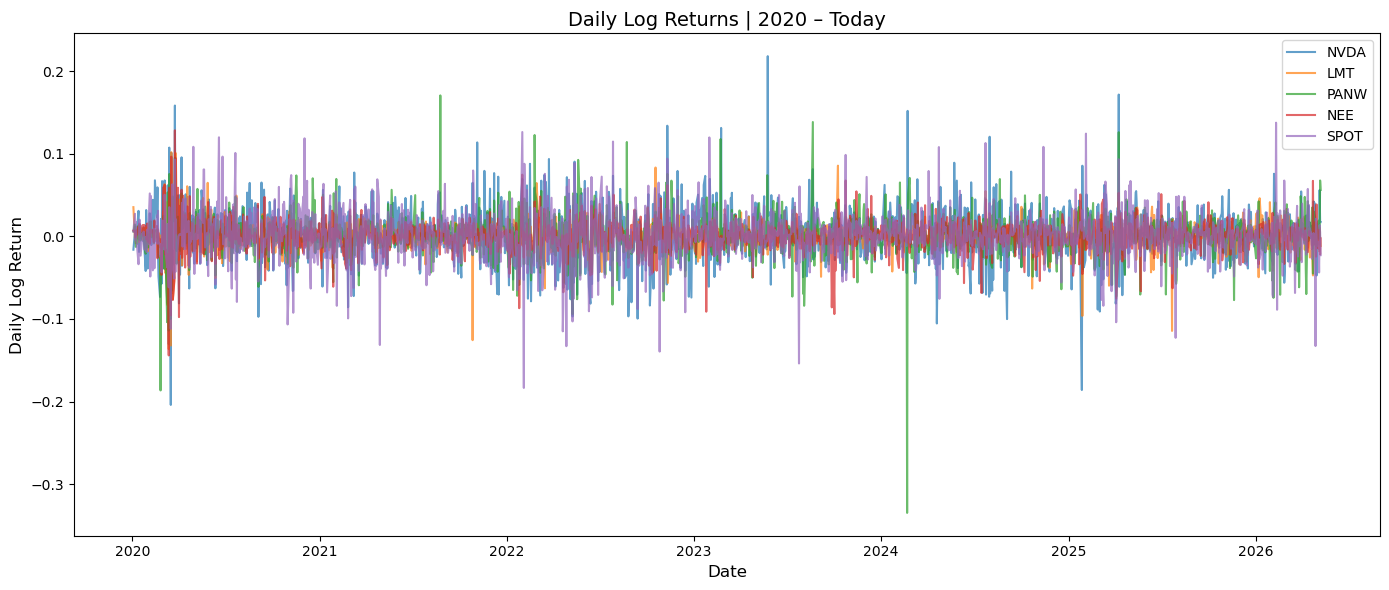

In [5]:
# ======================================================================
# SECTION 3 — Log Returns
# ======================================================================

log_return = np.log(data / data.shift(1))
 
plt.figure(figsize=(14, 6))
for col in log_return[stocks].columns:
    plt.plot(log_return[col], label=col, alpha=0.7)
 
plt.title("Daily Log Returns | 2020 – Today", fontsize=14)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Daily Log Return", fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

In [6]:
# ======================================================================
# SECTION 4 — Individual Asset Risk & Return (Stocks Only)
# ======================================================================

annual_return   = log_return[stocks].mean() * 250
annual_variance = log_return[stocks].var()  * 250
annual_std      = log_return[stocks].std()  * (250 ** 0.5)
 
summary_individual = pd.DataFrame({
    "Annual Return (%)":    (annual_return   * 100).round(2),
    "Annual Variance":       annual_variance.round(6),
    "Volatility / Risk (%)": (annual_std      * 100).round(2)
})
 
print("\n===== Individual Asset Risk & Return Summary =====")
print(summary_individual.to_string())


===== Individual Asset Risk & Return Summary =====
        Annual Return (%)  Annual Variance  Volatility / Risk (%)
Ticker                                                           
NVDA                56.19         0.269637                  51.93
LMT                  6.36         0.069951                  26.45
PANW                26.13         0.171501                  41.41
NEE                  9.41         0.087861                  29.64
SPOT                15.89         0.240784                  49.07


# Portfolio Construction

In [7]:
# ======================================================================
# SECTION 5 — Portfolio Construction
# ======================================================================

# Weights: NVDA=25%, LMT=20%, PANW=20%, NEE=15%, SPOT=20%
# Order must match the 'stocks' list: ["NVDA", "LMT", "PANW", "NEE", "SPOT"]

portfolio_weights = np.array([0.25, 0.20, 0.20, 0.15, 0.20])
assert round(portfolio_weights.sum(), 6) == 1.0, "Weights must sum to 1!"
print(f"\nWeights sum: {portfolio_weights.sum():.4f}")
 
# Annual return of the portfolio (weights aligned to stocks list)
annual_return_portfolio = log_return[stocks].mean() * 250
portfolio_return = np.dot(portfolio_weights, annual_return_portfolio)
 
print(f"Portfolio Annual Return: {round(portfolio_return * 100, 2)}%")



Weights sum: 1.0000
Portfolio Annual Return: 25.13%


# Covariance & Correlation Analysis

In [8]:
# ======================================================================
# SECTION 6 — Covariance & Correlation Analysis
# ======================================================================

# --- Covariance Matrix (stocks only, annualized) ---
annual_covariance = log_return[stocks].cov() * 250
 
print("\n===== Annual Covariance Matrix (Stocks Only) =====")
print(annual_covariance.round(6))


===== Annual Covariance Matrix (Stocks Only) =====
Ticker      NVDA       LMT      PANW       NEE      SPOT
Ticker                                                  
NVDA    0.269637  0.014508  0.098188  0.035878  0.112751
LMT     0.014508  0.069951  0.018293  0.026798  0.007033
PANW    0.098188  0.018293  0.171501  0.024654  0.074300
NEE     0.035878  0.026798  0.024654  0.087861  0.025274
SPOT    0.112751  0.007033  0.074300  0.025274  0.240784


In [9]:
# --- Correlation Matrix (NEVER * 250 — dimensionless) ---
correlation_matrix = log_return[stocks].corr()
 
print("\n===== Correlation Matrix =====")
print(correlation_matrix.round(3))
print("\nDiagonal check (must all be 1.0):", np.diag(correlation_matrix.values).round(3))


===== Correlation Matrix =====
Ticker   NVDA    LMT   PANW    NEE   SPOT
Ticker                                   
NVDA    1.000  0.106  0.457  0.233  0.443
LMT     0.106  1.000  0.167  0.342  0.054
PANW    0.457  0.167  1.000  0.201  0.366
NEE     0.233  0.342  0.201  1.000  0.174
SPOT    0.443  0.054  0.366  0.174  1.000

Diagonal check (must all be 1.0): [1. 1. 1. 1. 1.]


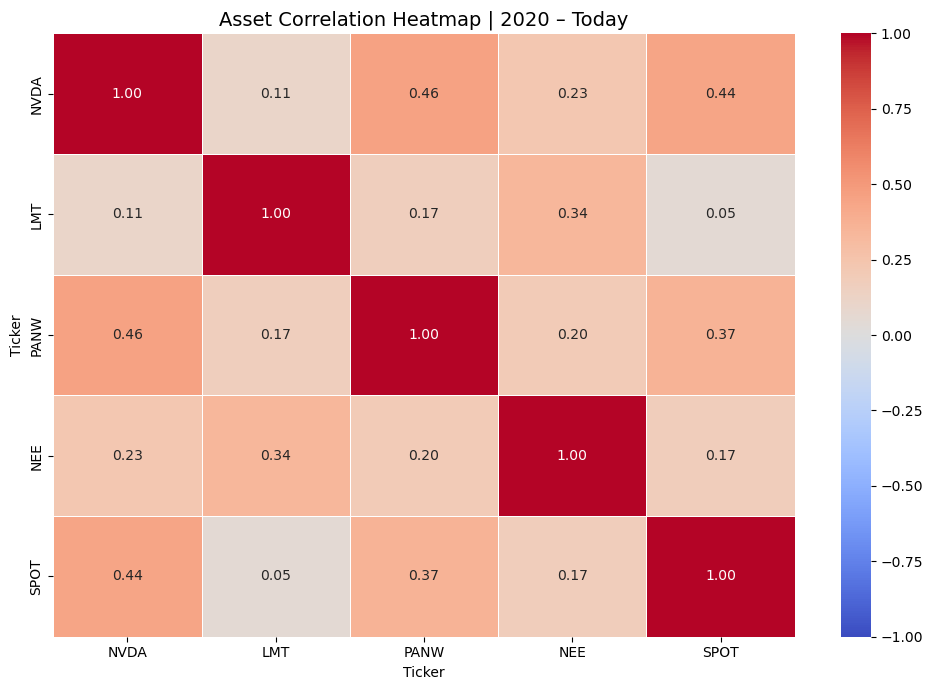

In [10]:
# --- Heatmap ---
plt.figure(figsize=(10, 7))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5,
    vmin=-1, vmax=1
)
plt.title("Asset Correlation Heatmap | 2020 – Today", fontsize=14)
plt.tight_layout()
plt.show()

# Portfolio Variance & Risk Decomposition

In [11]:
# ======================================================================
# SECTION 7 — Portfolio Variance & Volatility
# ======================================================================

portfolio_variance   = np.dot(portfolio_weights.T, np.dot(annual_covariance, portfolio_weights))
portfolio_volatility = portfolio_variance ** 0.5
 
print("\n===== Portfolio Variance & Volatility =====")
print(f"Variance  : {portfolio_variance:.6f}")
print(f"Volatility: {round(portfolio_volatility * 100, 2)}%")


===== Portfolio Variance & Volatility =====
Variance  : 0.075928
Volatility: 27.56%


# Systematic vs Diversifiable Risk

In [12]:
# ======================================================================
# SECTION 8 — Systematic vs Diversifiable Risk
# ======================================================================

def weighted_individual_variance(weights, variances):
    """Sum of w_i^2 * sigma_i^2 — variance if all assets were uncorrelated."""
    return np.sum(weights**2 * variances)
 
variances_stocks  = annual_variance[stocks].values
wiv               = weighted_individual_variance(portfolio_weights, variances_stocks)
diversifiable_risk = portfolio_variance - wiv        # removed by diversification
systematic_risk    = portfolio_variance - diversifiable_risk  # cannot be removed
 
print("\n===== Risk Decomposition =====")
print(f"Total Portfolio Variance : {portfolio_variance:.6f}")
print(f"Systematic Risk          : {systematic_risk:.6f}   (cannot be diversified away)")
print(f"Diversifiable Risk       : {diversifiable_risk:.6f}   (eliminated via diversification)")


===== Risk Decomposition =====
Total Portfolio Variance : 0.075928
Systematic Risk          : 0.038119   (cannot be diversified away)
Diversifiable Risk       : 0.037809   (eliminated via diversification)


# Regression Analysis

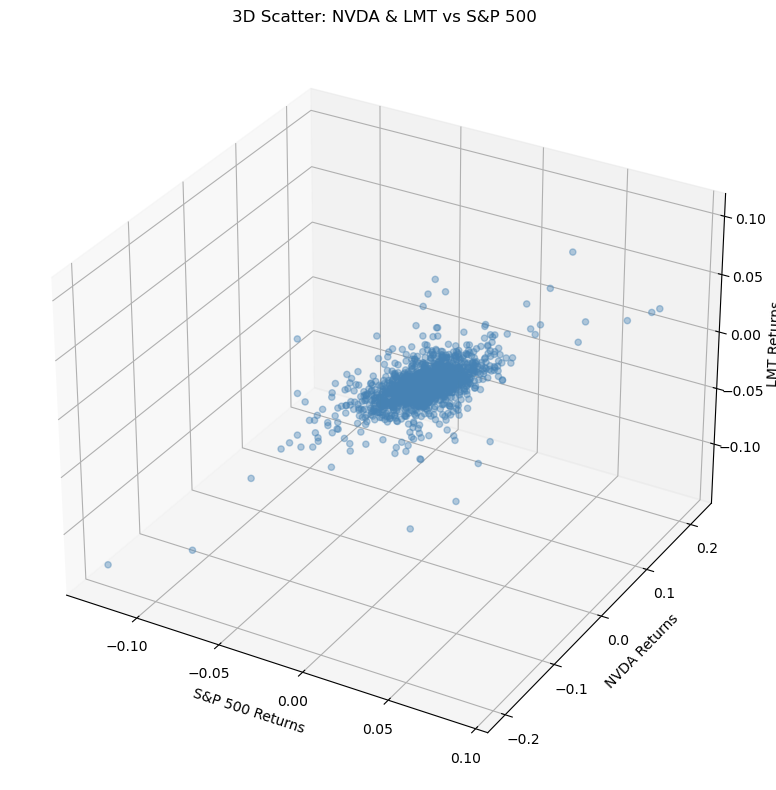

In [13]:
# ======================================================================
# SECTION 9 — Regression Analysis: Each Stock vs S&P 500
# ======================================================================

clean_data = log_return.dropna()
 
# --- 3D Scatter: NVDA & LMT vs Market ---
fig = plt.figure(figsize=(10, 8))
ax  = fig.add_subplot(111, projection="3d")
ax.scatter(
    clean_data["^GSPC"],
    clean_data["NVDA"],
    clean_data["LMT"],
    c="steelblue", marker="o", alpha=0.4
)
ax.set_xlabel("S&P 500 Returns")
ax.set_ylabel("NVDA Returns")
ax.set_zlabel("LMT Returns")
ax.set_title("3D Scatter: NVDA & LMT vs S&P 500")
plt.tight_layout()
plt.show()


In [14]:
# --- OLS Regressions ---
X_market = sm.add_constant(clean_data["^GSPC"])
 
regression_results = {}
 
for ticker in stocks:
    Y     = clean_data[ticker]
    model = sm.OLS(Y, X_market).fit()
    regression_results[ticker] = {
        "Beta"   : model.params["^GSPC"],
        "Alpha"  : model.params["const"],
        "R²"     : model.rsquared,
        "p-value": model.pvalues["^GSPC"]
    }
    print(f"\n{'='*50}")
    print(f"Model: {ticker} vs S&P 500")
    print(f"{'='*50}")
    print(model.summary())



Model: NVDA vs S&P 500
                            OLS Regression Results                            
Dep. Variable:                   NVDA   R-squared:                       0.497
Model:                            OLS   Adj. R-squared:                  0.496
Method:                 Least Squares   F-statistic:                     1572.
Date:                Sat, 09 May 2026   Prob (F-statistic):          9.58e-240
Time:                        13:31:13   Log-Likelihood:                 3733.4
No. Observations:                1595   AIC:                            -7463.
Df Residuals:                    1593   BIC:                            -7452.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0013      0

# Final Summary Dashboard

In [15]:
# ======================================================================
# SECTION 10 — Final Summary Dashboard
# ======================================================================

# --- Individual Asset Summary ---
print("\n\n" + "="*60)
print("       INDIVIDUAL ASSET RISK & RETURN SUMMARY")
print("="*60)
print(summary_individual.to_string())



       INDIVIDUAL ASSET RISK & RETURN SUMMARY
        Annual Return (%)  Annual Variance  Volatility / Risk (%)
Ticker                                                           
NVDA                56.19         0.269637                  51.93
LMT                  6.36         0.069951                  26.45
PANW                26.13         0.171501                  41.41
NEE                  9.41         0.087861                  29.64
SPOT                15.89         0.240784                  49.07


In [16]:
# --- Beta & Regression Summary ---
beta_summary = pd.DataFrame(regression_results).T
beta_summary["Beta"]    = beta_summary["Beta"].round(3)
beta_summary["Alpha"]   = beta_summary["Alpha"].round(6)
beta_summary["R²"]      = beta_summary["R²"].round(3)
beta_summary["p-value"] = beta_summary["p-value"].apply(lambda x: f"{x:.2e}")
 
print("\n" + "="*60)
print("       BETA & REGRESSION SUMMARY (vs S&P 500)")
print("="*60)
print(beta_summary.to_string())


       BETA & REGRESSION SUMMARY (vs S&P 500)
       Beta     Alpha     R²    p-value
NVDA  1.778  0.001333  0.497  9.58e-240
LMT   0.527 -0.000017  0.168   8.42e-66
PANW  1.050  0.000506  0.272  4.66e-112
NEE   0.728  0.000002  0.256  2.70e-104
SPOT  1.066  0.000088  0.200   3.52e-79


In [17]:
# --- Portfolio-Level Summary ---
summary_portfolio = pd.DataFrame({
    "Annual Return (%)":   [round(portfolio_return    * 100, 2)],
    "Volatility (%)":      [round(portfolio_volatility * 100, 2)],
    "Variance":            [round(portfolio_variance,         6)],
    "Systematic Risk":     [round(systematic_risk,            6)],
    "Diversifiable Risk":  [round(diversifiable_risk,         6)]
}, index=["Portfolio (NVDA/LMT/PANW/NEE/SPOT)"])
 
print("\n" + "="*60)
print("       FINAL PORTFOLIO SUMMARY")
print("="*60)
print(summary_portfolio.to_string())
 
print("\n Analysis complete.")


       FINAL PORTFOLIO SUMMARY
                                    Annual Return (%)  Volatility (%)  Variance  Systematic Risk  Diversifiable Risk
Portfolio (NVDA/LMT/PANW/NEE/SPOT)              25.13           27.56  0.075928         0.038119            0.037809

 Analysis complete.
